# PathSim Introduction

[PathSim](https://github.com/pathsim/pathsim) is a block-based, time-domain system simulation
framework for Python.  It lets you model dynamical systems graphically using *blocks* (sources,
integrators, functions, scopes, …) and *connections*, then simulate them with a choice of ODE solvers.

PathSim is particularly useful for:

* Rapid prototyping of control systems.
* Running hardware-in-the-loop (HIL) scenarios.
* Wrapping external simulation engines (e.g. JSBSim – see `04_pathsim_jsbsim_trim_elevator_doublet.ipynb`).

Documentation: [https://docs.pathsim.org](https://docs.pathsim.org)

### Install

```bash
pip install pathsim
# or
conda install conda-forge::pathsim
```

## 1. Imports

In [1]:
# If running on Google Colab, install the required packages.

import sys

if 'google.colab' in sys.modules:
    print('Running on Google Colab \u2013 installing pathsim \u2026')
    !pip install pathsim


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from pathsim import Simulation, Connection
from pathsim.blocks import (
    Integrator,
    Amplifier,
    Adder,
    Scope,
    Source,
    Constant,
    Function,
)
import pathsim

matplotlib.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.4})

print(f"PathSim version : {pathsim.__version__}")

PathSim version : 0.20.0


## 2. Example 1 – Damped harmonic oscillator

We model the second-order ODE

$$\ddot{x} + 2\zeta\omega_n \dot{x} + \omega_n^2 x = 0$$

with $\omega_n = 2\,\text{rad/s}$ and $\zeta = 0.25$ (under-damped).

The block diagram is:

```
Adder → Integrator(v0) → Integrator(x0) ──→ Scope
  ↑                ↓                ↓
  └── Amp(-2ζωn) ──┘    Amp(-ωn²) ──┘
```

17:50:13 - INFO - LOGGING (log: True)
17:50:13 - INFO - BLOCKS (total: 6, dynamic: 2, static: 4, eventful: 0)
17:50:13 - INFO - GRAPH (nodes: 6, edges: 8, alg. depth: 3, loop depth: 0, runtime: 0.074ms)
17:50:13 - INFO - STARTING -> TRANSIENT (Duration: 20.00s)
17:50:13 - INFO - --------------------   1% | 0.0s<0.3s | 6273.2 it/s
17:50:13 - INFO - ####----------------  20% | 0.0s<0.1s | 13153.6 it/s
17:50:13 - INFO - ########------------  40% | 0.1s<0.1s | 13248.0 it/s
17:50:13 - INFO - ############--------  60% | 0.1s<0.1s | 13216.5 it/s
17:50:13 - INFO - ################----  80% | 0.2s<0.0s | 13333.4 it/s
17:50:13 - INFO - #################### 100% | 0.2s<--:-- | 8292.8 it/s
17:50:13 - INFO - FINISHED -> TRANSIENT (total steps: 2000, successful: 2000, runtime: 216.42 ms)


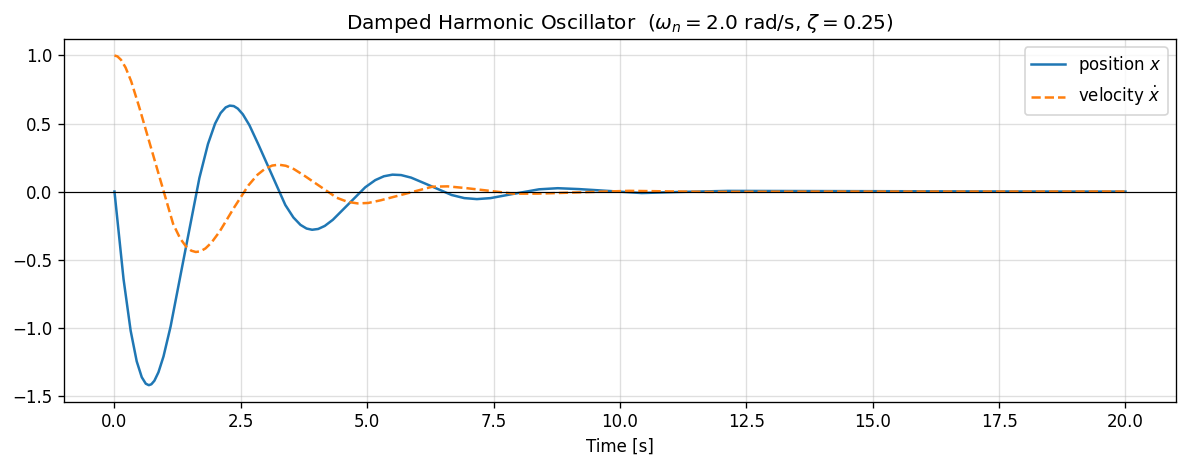

In [3]:
omega_n = 2.0   # natural frequency [rad/s]
zeta    = 0.25  # damping ratio

# Initial conditions: x0 = 1, v0 = 0
int_v = Integrator(0.0)                # integrates acceleration → velocity
int_x = Integrator(1.0)                # integrates velocity   → position
amp_d = Amplifier(-2 * zeta * omega_n) # damping term
amp_k = Amplifier(-omega_n**2)         # stiffness term
adder = Adder()
scope = Scope(labels=['position x', 'velocity v'])

sim1 = Simulation(
    blocks=[int_v, int_x, amp_d, amp_k, adder, scope],
    connections=[
        Connection(int_v, int_x, amp_d),        # v  → x-dot and damping amp
        Connection(int_x, amp_k, scope[1]),      # x  → stiffness amp and scope ch-1
        Connection(amp_d, adder),                # damping → adder ch-0
        Connection(amp_k, adder[1]),             # stiffness → adder ch-1
        Connection(adder, int_v),                # sum → x-ddot
        Connection(int_v, scope[0]),             # v   → scope ch-0  (reorder display)
    ],
    dt=0.01
)

sim1.run(20)

t, scope_data = scope.read()
x_data, v_data = scope_data[0], scope_data[1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x_data, label='position $x$', linewidth=1.5)
ax.plot(t, v_data, label='velocity $\\dot{x}$', linewidth=1.5, linestyle='--')
ax.axhline(0, color='k', linewidth=0.7)
ax.set_xlabel('Time [s]')
ax.set_title(
    f'Damped Harmonic Oscillator  '
    f'($\\omega_n={omega_n}$ rad/s, $\\zeta={zeta}$)'
)
ax.legend()
plt.tight_layout()
plt.savefig('harmonic_oscillator.png', bbox_inches='tight')
plt.show()

## 3. Example 2 – First-order system step response

A first-order linear system driven by a unit step:

$$\tau \dot{y} + y = u(t), \quad u(t) = 1 \text{ for } t \ge 0$$

The analytical solution is $y(t) = 1 - e^{-t/\tau}$.

17:50:13 - INFO - LOGGING (log: True)
17:50:13 - INFO - BLOCKS (total: 5, dynamic: 1, static: 4, eventful: 0)
17:50:13 - INFO - GRAPH (nodes: 5, edges: 6, alg. depth: 3, loop depth: 0, runtime: 0.062ms)
17:50:13 - INFO - STARTING -> TRANSIENT (Duration: 15.00s)
17:50:13 - INFO - --------------------   1% | 0.0s<0.2s | 9091.5 it/s
17:50:13 - INFO - ####----------------  20% | 0.0s<0.1s | 14896.4 it/s
17:50:13 - INFO - ########------------  40% | 0.1s<0.1s | 16317.4 it/s
17:50:13 - INFO - ############--------  60% | 0.1s<0.0s | 16551.2 it/s
17:50:13 - INFO - ################----  80% | 0.1s<0.0s | 16171.9 it/s
17:50:13 - INFO - #################### 100% | 0.2s<--:-- | 7332.9 it/s
17:50:13 - INFO - FINISHED -> TRANSIENT (total steps: 1501, successful: 1501, runtime: 152.46 ms)


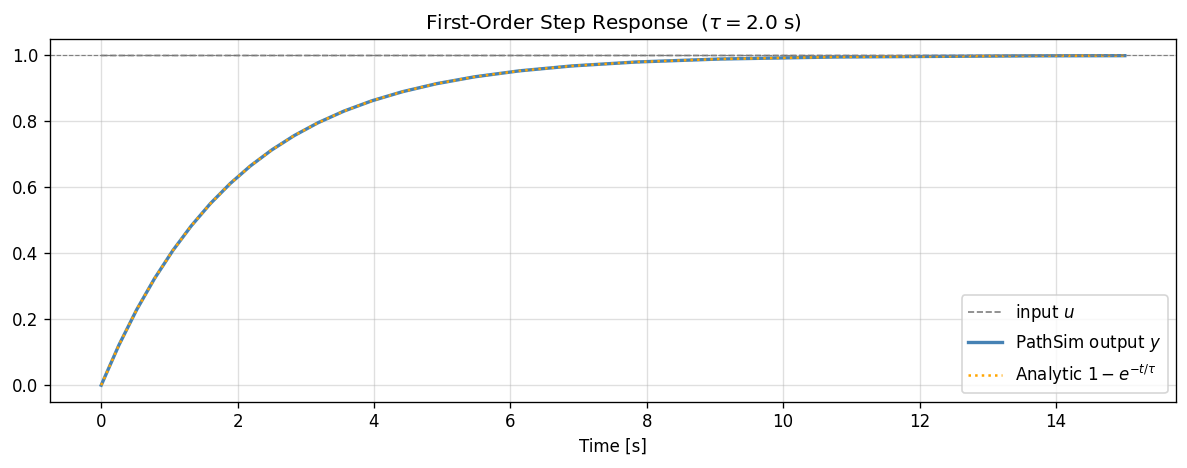

Max absolute error vs analytical: 1.54e-06


In [4]:
tau = 2.0  # time constant [s]

step_src  = Constant(1.0)                    # unit step input
adder2    = Adder('+-') # error = u - y
amp_tau   = Amplifier(1.0 / tau)             # 1/τ
integr    = Integrator(0.0)                  # state y
scope2    = Scope(labels=['y', 'u'])

sim2 = Simulation(
    blocks=[step_src, adder2, amp_tau, integr, scope2],
    connections=[
        Connection(step_src, adder2, scope2[1]),  # u → error adder and scope
        Connection(integr, adder2[1], scope2[0]), # y → error adder (neg) and scope
        Connection(adder2, amp_tau),               # error → 1/τ
        Connection(amp_tau, integr),               # ẏ = (u-y)/τ
    ],
    dt=0.01
)

sim2.run(15)

t2, scope2_data = scope2.read()
y2, u2 = scope2_data[0], scope2_data[1]
y_analytic = 1 - np.exp(-np.array(t2) / tau)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t2, u2, 'k--', linewidth=1.0, label='input $u$', alpha=0.5)
ax.plot(t2, y2, color='steelblue', linewidth=2.0, label='PathSim output $y$')
ax.plot(t2, y_analytic, color='orange', linewidth=1.5,
        linestyle=':', label='Analytic $1-e^{-t/\\tau}$')
ax.axhline(1.0, color='grey', linewidth=0.7, linestyle='--')
ax.set_xlabel('Time [s]')
ax.set_title(f'First-Order Step Response  ($\\tau = {tau}$ s)')
ax.legend()
plt.tight_layout()
plt.savefig('first_order_step.png', bbox_inches='tight')
plt.show()

max_err = np.max(np.abs(np.array(y2) - y_analytic))
print(f"Max absolute error vs analytical: {max_err:.2e}")

## 4. Example 3 – Sinusoidal source and phase portrait

PathSim provides a `Source` block that wraps an arbitrary time-varying function.

17:50:14 - INFO - LOGGING (log: True)
17:50:14 - INFO - BLOCKS (total: 5, dynamic: 2, static: 3, eventful: 0)
17:50:14 - INFO - GRAPH (nodes: 5, edges: 8, alg. depth: 3, loop depth: 0, runtime: 0.059ms)
17:50:14 - INFO - STARTING -> TRANSIENT (Duration: 40.00s)
17:50:14 - INFO - --------------------   1% | 0.0s<0.3s | 11559.2 it/s
17:50:14 - INFO - ####----------------  20% | 0.1s<0.2s | 13335.1 it/s
17:50:14 - INFO - ########------------  40% | 0.2s<0.2s | 13358.3 it/s
17:50:14 - INFO - ############--------  60% | 0.2s<0.1s | 13528.1 it/s
17:50:14 - INFO - ################----  80% | 0.3s<0.1s | 13617.3 it/s
17:50:14 - INFO - #################### 100% | 0.4s<--:-- | 13110.2 it/s
17:50:14 - INFO - FINISHED -> TRANSIENT (total steps: 4000, successful: 4000, runtime: 360.43 ms)


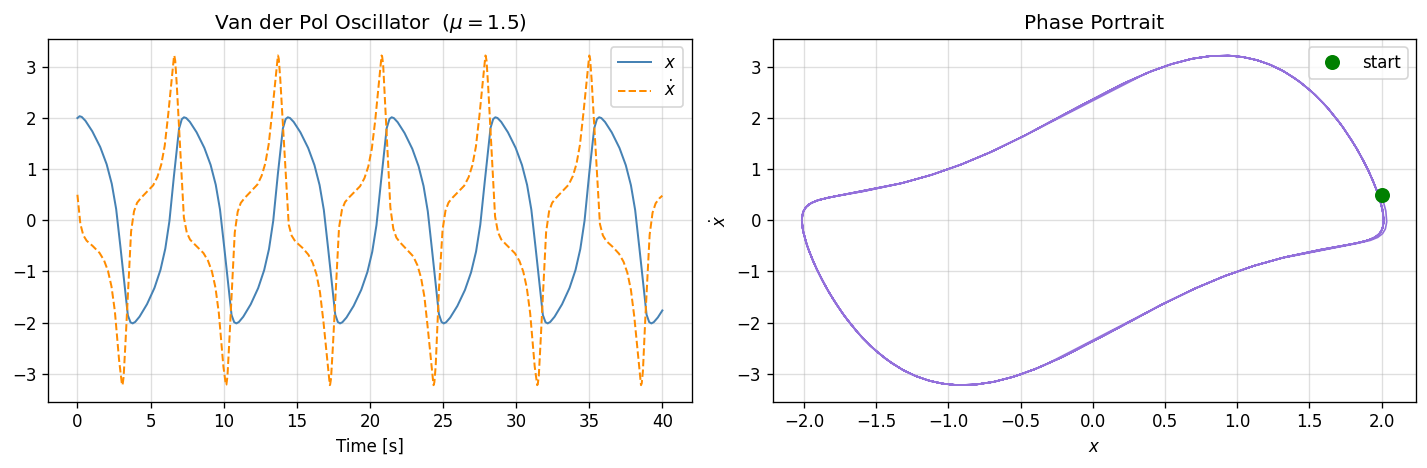

In [5]:
import math

# Van der Pol oscillator:  x'' - μ(1-x²)x' + x = 0
mu = 1.5

int_vdp_v = Integrator(0.5)   # ẋ,  initial velocity
int_vdp_x = Integrator(2.0)   # x,  initial position

# The nonlinear damping term μ(1-x²)ẋ
def vdp_nonlinear(x, v):
    return mu * (1 - x**2) * v

nl_block  = Function(vdp_nonlinear)
adder_vdp = Adder('+-')
scope_vdp = Scope(labels=['x', 'v'])

sim3 = Simulation(
    blocks=[int_vdp_v, int_vdp_x, nl_block, adder_vdp, scope_vdp],
    connections=[
        Connection(int_vdp_v, int_vdp_x, nl_block[1], scope_vdp[1]),  # v
        Connection(int_vdp_x, nl_block[0], scope_vdp[0]),              # x
        Connection(nl_block, adder_vdp),                                # μ(1-x²)v
        Connection(int_vdp_x, adder_vdp[1]),                           # x (→ -x)
        Connection(adder_vdp, int_vdp_v),                              # ẍ
    ],
    dt=0.01
)

sim3.run(40)

t3, vdp_data = scope_vdp.read()
x3, v3 = vdp_data[0], vdp_data[1]
x3, v3 = np.array(x3), np.array(v3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t3, x3, linewidth=1.2, label='$x$', color='steelblue')
axes[0].plot(t3, v3, linewidth=1.2, label='$\\dot{x}$',
             color='darkorange', linestyle='--')
axes[0].set_xlabel('Time [s]')
axes[0].set_title(f'Van der Pol Oscillator  ($\\mu={mu}$)')
axes[0].legend()

axes[1].plot(x3, v3, linewidth=1.0, color='mediumpurple')
axes[1].plot(x3[0], v3[0], 'go', ms=8, label='start')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$\\dot{x}$')
axes[1].set_title('Phase Portrait')
axes[1].legend()

plt.tight_layout()
plt.savefig('van_der_pol.png', bbox_inches='tight')
plt.show()

## 5. PathView

[PathView](https://view.pathsim.org) is the graphical block-diagram editor for PathSim.
You can:

1. **Design** your block diagram visually in the browser.
2. **Export** the diagram as a Python script.
3. **Run** the exported script in this environment.

The exported Python file uses the same `Simulation`, `Connection`, and `Block` API shown above.

In [6]:
from IPython.display import IFrame

# Display PathView in an iframe (requires internet access)
IFrame(src='https://view.pathsim.org', width='100%', height=500)

## Summary

You have seen three examples of PathSim block-diagram simulation:

1. **Damped harmonic oscillator** – second-order ODE via two cascaded integrators.
2. **First-order step response** – verified against an analytical solution.
3. **Van der Pol oscillator** – nonlinear system with a custom `Function` block and phase portrait.

**Next:** [04_pathsim_jsbsim_trim_elevator_doublet.ipynb](04_pathsim_jsbsim_trim_elevator_doublet.ipynb) – embedding JSBSim directly in a PathSim block diagram (trim + elevator doublet).
